In [19]:
from scMM.file._anndata import MetaboData
import pandas as pd

df = pd.read_csv("/home/zby/scMM/data/ethology_new/Compound_measurements.csv")
sample_mask = df.columns.to_series().str.match(r"^WORM-\d{8}$")
IS_MASK = df["IS"].values == "x"
IS_inten = df.loc[IS_MASK, :]
df = df.loc[IS_MASK == False, :]
high_mean = df["Highest Mean"].values
low_mean = df["Lowest Mean"].values
FC = df["Max Fold Change"].values
data = MetaboData(
    X = df.loc[:, sample_mask].values.T,
    obs = pd.DataFrame({
        "name": df.columns[sample_mask].values
    }),
    var = pd.DataFrame({
        "mz": df["m/z"].values,
        "rt": df["Retention time (min)"].values,
        "isotope": df["Isotope Distribution"].values,
        "snr": [FC[i] if high_mean[i] == "Condition 1" else 1/FC[i] for i in range(len(FC))],
        "identification": df["Accepted Description"].values
    }),
    is_inten = IS_inten.loc[:, sample_mask].T
)

/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [17]:
print(data.X, data.is_inten)
data.is_calibration()
print(data.X)

[[1.56821351e+02 8.25418998e+01 2.51004769e+02 ... 8.10781366e+01
  9.91009790e+02 6.74255351e+01]
 [1.86139752e+02 2.56462995e+02 4.32409940e+02 ... 2.75574057e+02
  2.66989244e+03 2.23502089e+02]
 [1.77745688e+02 5.63737381e+01 1.86054455e+02 ... 1.37816427e+02
  1.14133720e+03 9.43359504e+01]
 ...
 [1.14572698e+02 5.85053081e+01 1.81323356e+02 ... 3.89121823e+01
  3.44283340e+02 2.77782684e+01]
 [1.10459954e+02 3.73763257e+00 1.46381124e+02 ... 0.00000000e+00
  1.56336460e+02 2.95699072e+00]
 [9.81617558e+01 6.23635194e+01 1.74920019e+02 ... 4.91853792e-01
  1.14825943e+02 4.07161436e+00]]                         15           25   ...           204           216
WORM-01252130  19184.736660  2438.303788  ...  13571.322980   6846.468597
WORM-01252200  26068.032430  3084.477879  ...  11252.424990   7001.638171
WORM-01252230  23664.893060  3686.896353  ...  12102.545360   5852.372895
WORM-01252300  22796.866720  3055.087590  ...   8484.807523   6033.163242
WORM-01252330  23324.781580  2

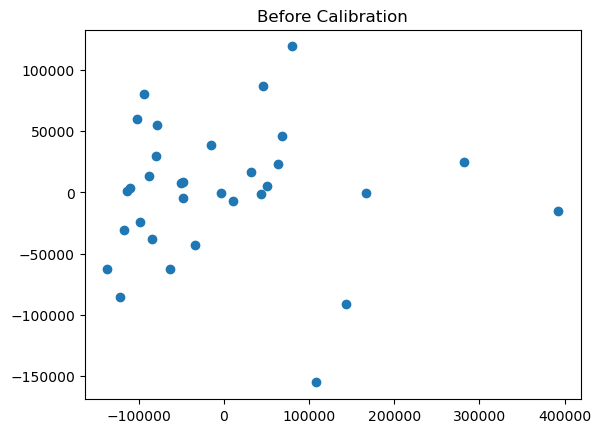

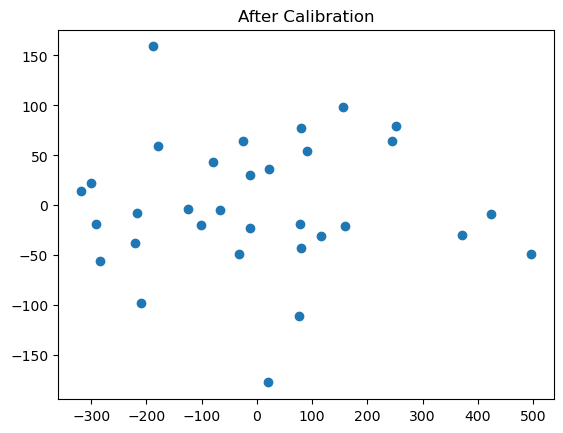

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
decomp = pca.fit_transform(data.X)
plt.scatter(decomp[:, 0], decomp[:, 1])
plt.title("Before Calibration")
plt.show()
data.is_calibration()
decomp = pca.fit_transform(data.X)
plt.scatter(decomp[:, 0], decomp[:, 1])
plt.title("After Calibration")
plt.show()